In [10]:
# General use
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Path related
import os
from pathlib import Path

# utils
from string import ascii_lowercase

# CNN related
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split

In [11]:
BATCH_SIZE = 128
RATIO_VALIDATION = 0.25
IMG_SIZE = 28
WORKERS = 4

LATENT_DIM = 100
SIZE_IMAGES = 28
NUM_CHANNELS = 1
NUM_EPOCHS = 100

LEARNING_RATE = 0.0002
BETA1 = 0.5

transform = transforms.Compose(
    [
        transforms.ToTensor(),  # Convierte (H, W, 1) a (1, H, W)
        transforms.Normalize((0.5,), (0.5,)),  # Normaliza a [-1, 1] para 1 canal
    ]
)

ngpus: int = torch.cuda.device_count()
device: torch.device = torch.device("cuda" if ngpus > 0 and False else "cpu")

SAVE_PATH = "../models/runs/translation/train"

In [12]:
def get_save_path() -> str:
    """
    Get the path to save the model.
    """
    global SAVE_PATH
    tmp = SAVE_PATH
    os.makedirs(tmp, exist_ok=True)

    while os.path.exists(tmp):
        if not os.path.exists(tmp):
            break

        if len(os.listdir(tmp)) == 0:
            break

        last_char = tmp[-1]
        if last_char.isdigit():
            tmp = tmp[:-1] + str(int(last_char) + 1)
        else:
            tmp = tmp + "2"
    
    os.makedirs(tmp, exist_ok=True)
    return tmp

## Custom Dataset

In [13]:
class CustomDataset(Dataset):
    ALLOWED_EXTENSIONS: list[str] = [".jpg", ".jpeg", ".png"]

    def __init__(self, root: str, transform: transforms.Compose | None = None) -> None:
        if not os.path.exists(root):
            raise FileNotFoundError(f"Path {root} does not exist")

        self.root: Path = Path(root)
        self.transform = transform

        images_path = [
            list(self.root.rglob(f"*{ext}")) for ext in self.ALLOWED_EXTENSIONS
        ]

        self.imgs_path: list[Path] = [
            item for sublist in images_path for item in sublist
        ]

    def map_label(self, label: str, characters_lowercase: str = ascii_lowercase) -> int:
        label = label.lower().split(".")[0]
        label = label[
            0
        ]  # TODO: CHANGE THE WAY TO GET THE LABEL, THERE'S MUST BE A BETTER WAY

        return characters_lowercase.index(label)

    def __len__(self) -> int:
        return len(self.imgs)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        img_path = self.imgs_path[index]

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        img = img.astype(np.float32) / 255.0  # Normaliza a [0, 1]

        label = self.map_label(img_path.name)
        label = torch.tensor(label, dtype=torch.uint8)

        if self.transform:
            img = self.transform(img)
        else:
            img = torch.from_numpy(img).float()

        # if ngpus > 0:
        #     img = torch.cuda.FloatTensor(img)
        #     label = label.to(device)

        return img, label

    # DataLoader requires to have this property
    @property
    def imgs(self) -> list[Path]:
        return self.imgs_path


In [14]:
custom_dataset = CustomDataset(root="../data/processed/kaggle", transform=transform)
dataloader = DataLoader(
    custom_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=WORKERS
)

In [15]:
data_iter = iter(dataloader)
images, labels = next(data_iter)
print(f"images shape: {images.shape}")
print(f"labels shape: {labels.shape}")

images shape: torch.Size([128, 1, 28, 28])
labels shape: torch.Size([128])


In [16]:
train_size = int(len(custom_dataset) * (1 - RATIO_VALIDATION))
validation_size = len(custom_dataset) - train_size

dataset_train, dataset_val = random_split(
    custom_dataset, [train_size, validation_size], generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)

# Train set
data_iter = iter(train_loader)
images, labels = next(data_iter)
print("TRAIN")
print(f"\ttrain size: {train_size}")
print(f"\timages shape: {images.shape}")
print(f"\tlabels shape: {labels.shape}")

# Validation set
data_iter = iter(val_loader)
images, labels = next(data_iter)
print("\nVALIDATION")
print(f"\tvalidation size: {validation_size}")
print(f"\timages shape: {images.shape}")
print(f"\tlabels shape: {labels.shape}")

TRAIN
	train size: 1170
	images shape: torch.Size([128, 1, 28, 28])
	labels shape: torch.Size([128])

VALIDATION
	validation size: 390
	images shape: torch.Size([128, 1, 28, 28])
	labels shape: torch.Size([128])


## Translation CNN

### Architecture

In [17]:
class BrailleCNN(nn.Module):
    def __init__(self, num_classes=len(ascii_lowercase)) -> None:
        super().__init__()
        self.model = nn.Sequential(
            # Bloque 1
            nn.Conv2d(
                in_channels=1, out_channels=64, kernel_size=5, stride=1, padding="same"
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            # Bloque 2
            nn.Conv2d(
                in_channels=64, out_channels=64, kernel_size=3, stride=1, padding="same"
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
            nn.BatchNorm2d(64),
            # Bloque 3
            nn.Conv2d(
                in_channels=64, out_channels=64, kernel_size=3, stride=1, padding="same"
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
            nn.BatchNorm2d(64),
            # Capas fully connected
            nn.Flatten(),
            nn.Linear(in_features=64 * 3 * 3, out_features=576),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.BatchNorm1d(576),
            nn.Linear(in_features=576, out_features=288),
            nn.ReLU(inplace=True),
            # Capa de salida
            nn.Linear(in_features=288, out_features=num_classes),
            nn.Softmax(dim=1),
        )

    def forward(self, x):
        return self.model(x)
    

net = BrailleCNN().to(device)

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))

### Train

In [29]:
losses = []
accuracies = []
best_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    for i, (inputs, labels) in enumerate(train_loader, 0):
        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Accuracy
        _, predicted = torch.max(outputs, 1)
        correct = (predicted == labels).sum().item()
        accuracy = correct / labels.size(0)

        # Stats
        losses.append(loss.item())
        accuracies.append(accuracy)

        if loss < best_loss:
            best_loss = loss
            best_model = {
                "epoch": epoch,
                "model_state_dict": net.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": loss,
                "accuracy": accuracy,
            }

        print(f'[{epoch + 1}, {i + 1:2d}] loss: {loss.item():.3f} -- accuracy: {accuracy:.3f}')

print('Finished Training')

[1,  1] loss: 2.396 -- accuracy: 0.930
[1,  2] loss: 2.375 -- accuracy: 0.953
[1,  3] loss: 2.385 -- accuracy: 0.945
[1,  4] loss: 2.361 -- accuracy: 0.969
[1,  5] loss: 2.368 -- accuracy: 0.961
[1,  6] loss: 2.364 -- accuracy: 0.961
[1,  7] loss: 2.387 -- accuracy: 0.938
[1,  8] loss: 2.413 -- accuracy: 0.914
[1,  9] loss: 2.418 -- accuracy: 0.906
[1, 10] loss: 2.371 -- accuracy: 0.944
[2,  1] loss: 2.381 -- accuracy: 0.945
[2,  2] loss: 2.364 -- accuracy: 0.969
[2,  3] loss: 2.400 -- accuracy: 0.930
[2,  4] loss: 2.368 -- accuracy: 0.961
[2,  5] loss: 2.385 -- accuracy: 0.938
[2,  6] loss: 2.400 -- accuracy: 0.930
[2,  7] loss: 2.406 -- accuracy: 0.922
[2,  8] loss: 2.375 -- accuracy: 0.953
[2,  9] loss: 2.387 -- accuracy: 0.938
[2, 10] loss: 2.382 -- accuracy: 0.944
[3,  1] loss: 2.373 -- accuracy: 0.953
[3,  2] loss: 2.375 -- accuracy: 0.953
[3,  3] loss: 2.409 -- accuracy: 0.922
[3,  4] loss: 2.383 -- accuracy: 0.945
[3,  5] loss: 2.389 -- accuracy: 0.938
[3,  6] loss: 2.405 -- ac

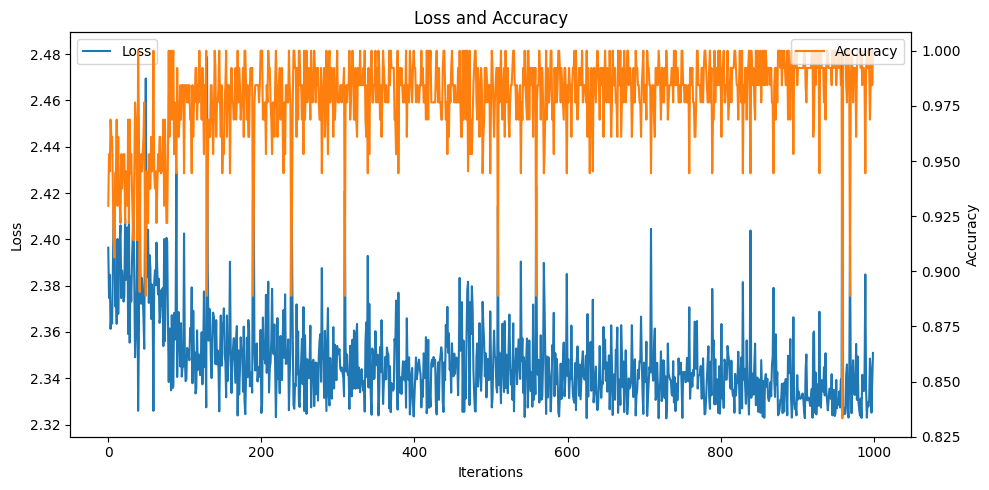

In [30]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set(title="Loss and Accuracy", xlabel="Iterations", ylabel="Loss")
ax1.plot(losses, label="Loss", color="tab:blue")

ax2 = ax1.twinx()
ax2.set(ylabel="Accuracy")
ax2.plot(accuracies, label="Accuracy", color="tab:orange")

fig.tight_layout()
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()

### Save

In [31]:
filename = f'best_model_epoch{best_model["epoch"]}.pth'
save_path = os.path.join(get_save_path(), filename)
torch.save(best_model, save_path)

In [32]:
save_path

'../models/runs/translation/train3/best_model_epoch72.pth'

## Validate & Load

1st version. This must be upgraded

In [33]:
save_path = "../models/runs/translation/train3/best_model_epoch72.pth"

In [37]:
checkpoint = torch.load(save_path, weights_only=True)
net.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
epoch = checkpoint["epoch"]
loss = checkpoint["loss"]
accuracy = checkpoint["accuracy"]
print(f"Cargado modelo de la época {epoch}, con pérdida {loss:.4f} y exactitud {accuracy:.4%}")

Cargado modelo de la época 72, con pérdida 2.3227 y exactitud 100.0000%


Accuracy of the network on the 390 test images: 96.923077%


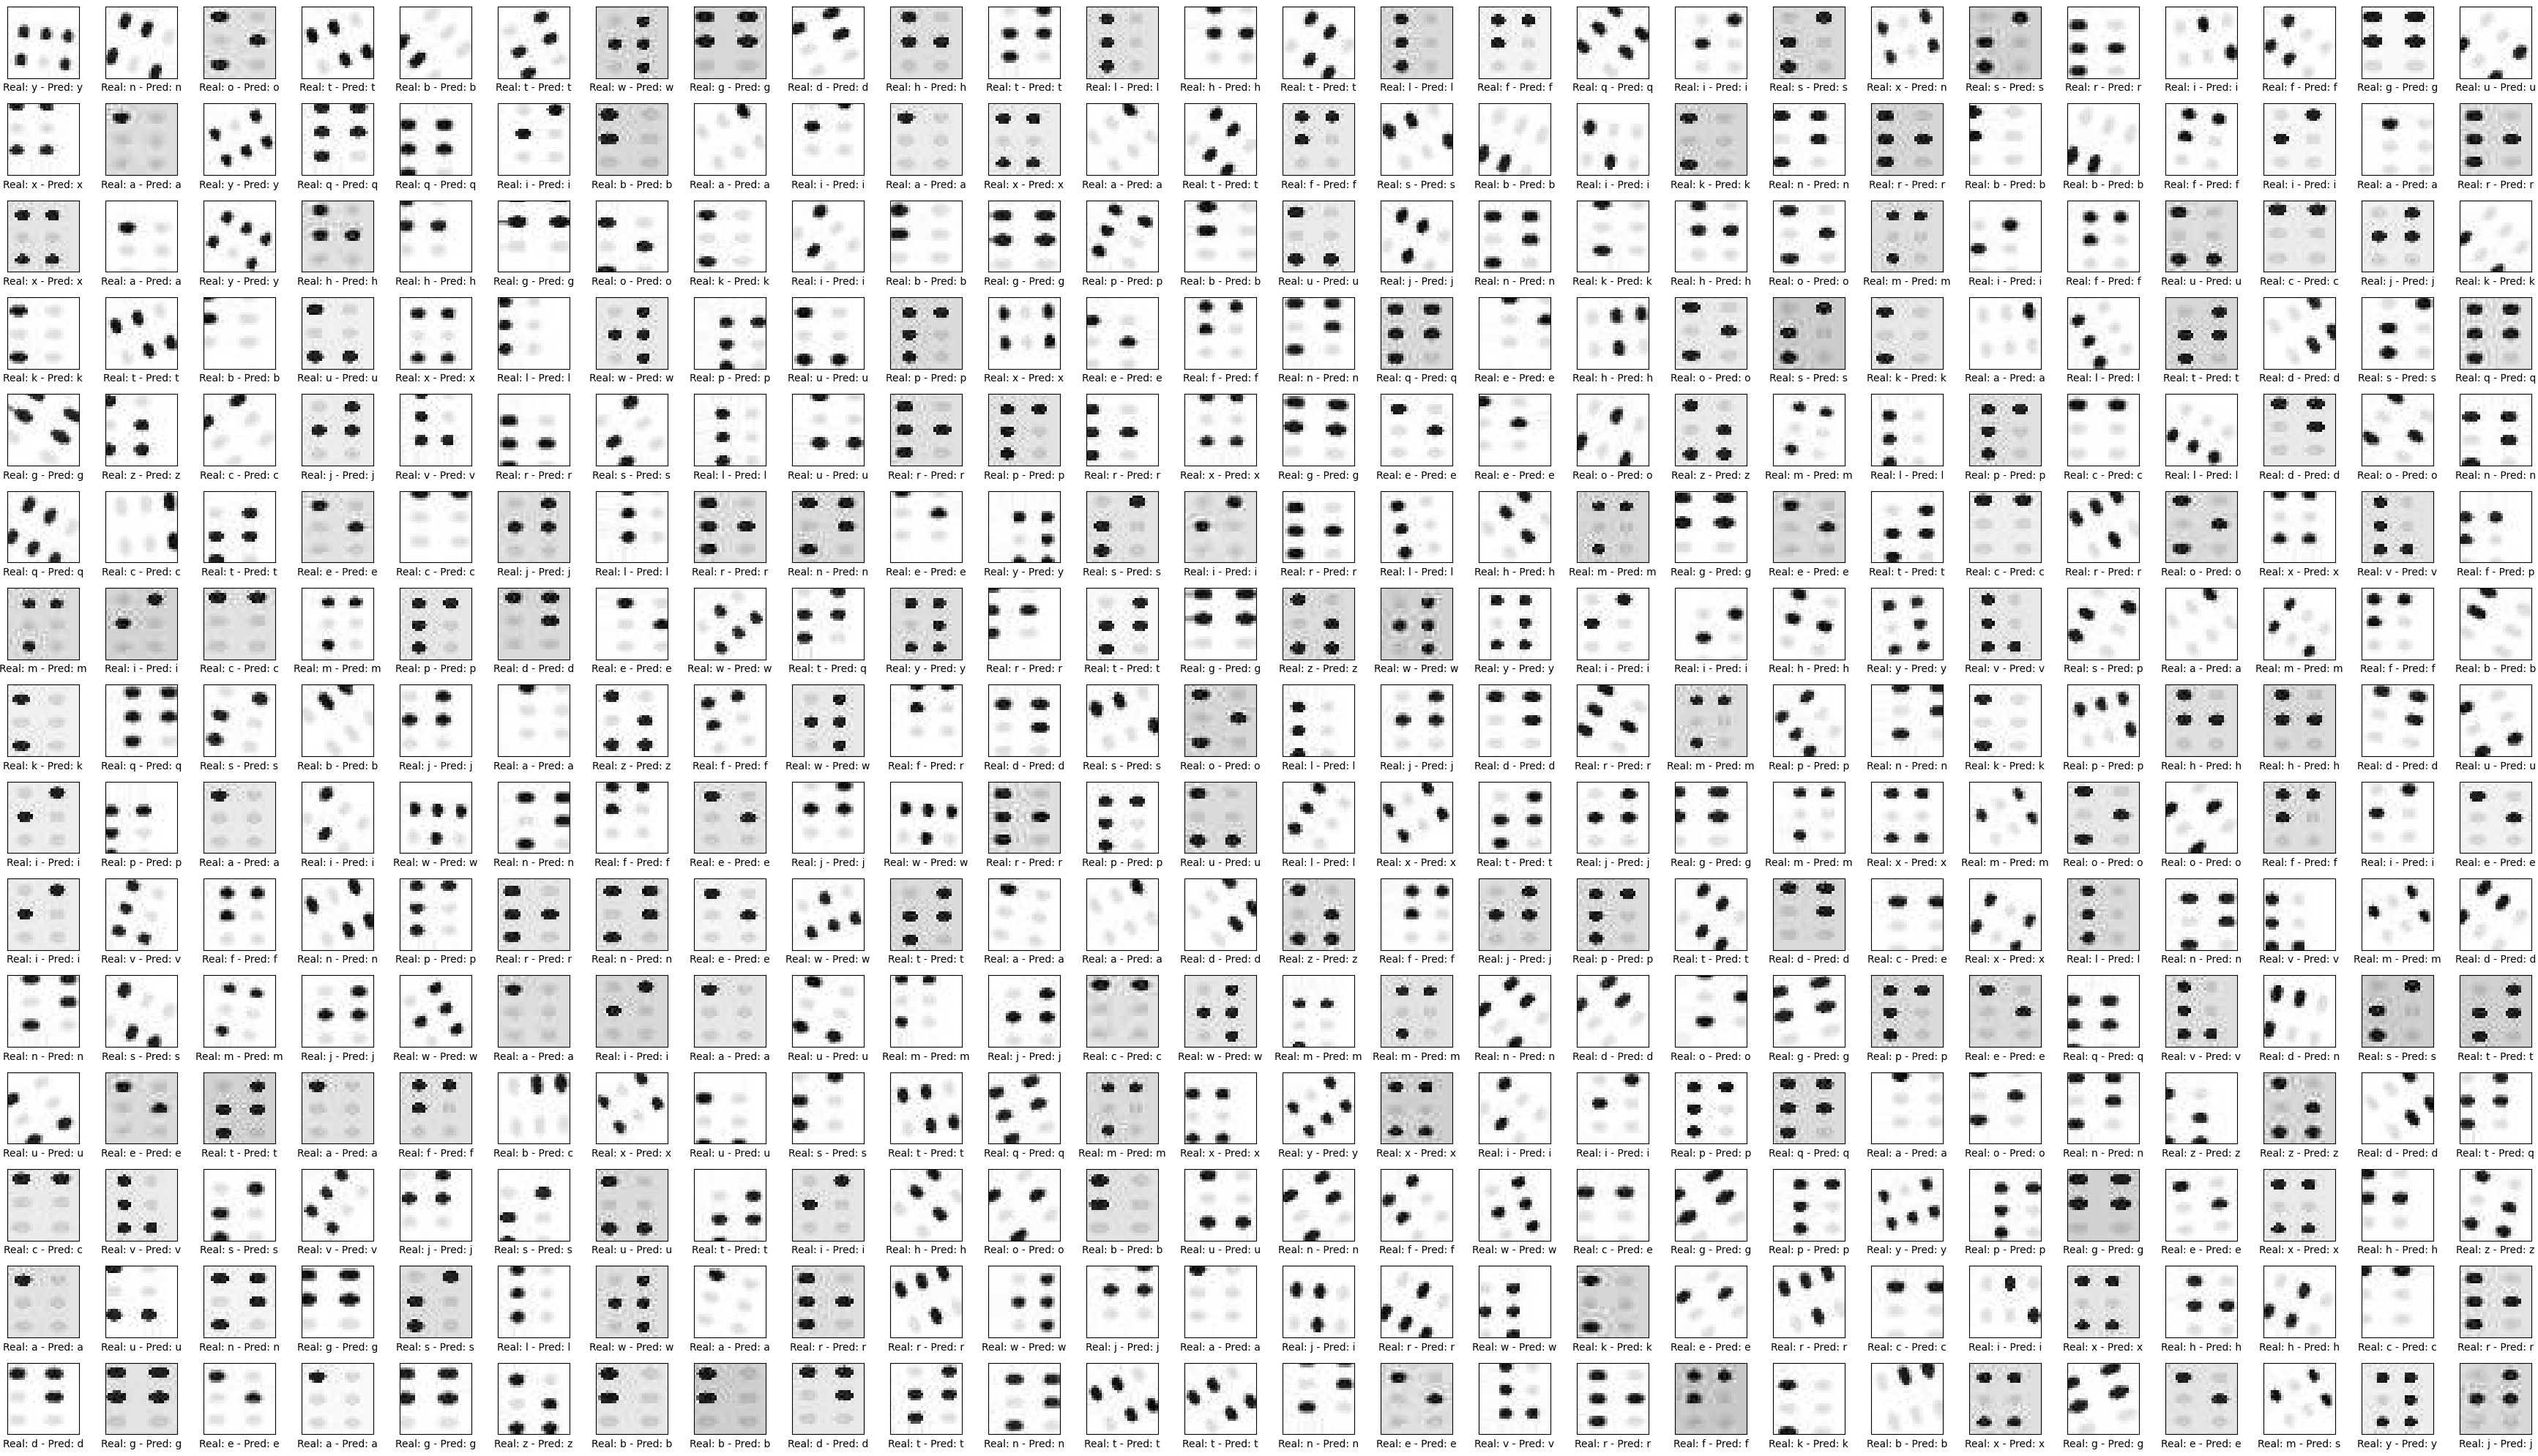

In [40]:
fig, axes = plt.subplots(15, 26, figsize=(35, 20))

dataiter = iter(val_loader)
images, labels = next(dataiter)

correct = 0
total = 0

axes_flatten = axes.flatten()
cont = 0
with torch.no_grad():
    for data in val_loader:
        images, labels = data

        # calculate outputs by running images through the network
        outputs = net(images)

        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        images = images.numpy().reshape(
            images.shape[0], images.shape[2], images.shape[3]
        )  # (batch_size, height, width)
        for i in range(images.shape[0]):
            img = images[i, :, :]

            ax = axes_flatten[cont]

            character_predicted = ascii_lowercase[predicted[i]]
            character_label = ascii_lowercase[labels[i]]
            ax.set(
                xticks=[], yticks=[],
                xlabel=f"Real: {character_label} - Pred: {character_predicted}"
            )
            ax.imshow(img, cmap="gray")
            cont += 1

print(f"Accuracy of the network on the {validation_size} test images: {correct / total:%}")

fig.tight_layout()
plt.show()